In [1]:
import pandas as pd
import numpy as np

path=r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\data\proceessed\flood_training_data_10k_clean.csv"
df = pd.read_csv(path)
df.head()

,easting,northing,point_id,distance_to_river,aspect,dem,flow_accumulation,twi,slope,flood,rainfall,drainage_density,ext_rainfall,lulc,soil
0,133952.230146,2.249638e+06,0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,0,1714.680084,0.008238,30.779120,40,29
1,206784.841335,2.468185e+06,1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,0,1561.825018,0.006385,34.464436,40,30
2,459671.933327,2.241227e+06,2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,0,1767.091847,0.045409,36.737860,80,36
3,44328.737440,2.570529e+06,3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,0,1424.827479,0.024082,32.841915,10,31
4,60077.196604,2.480489e+06,4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,0,1839.188680,0.027140,32.228870,50,31


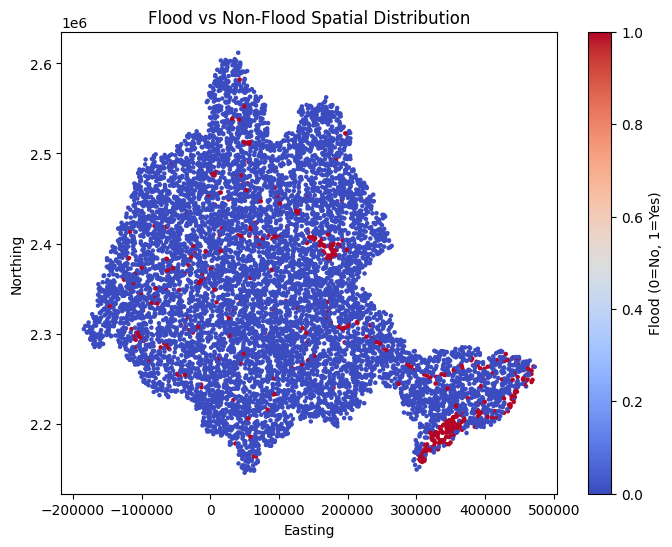

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["easting"],
    df["northing"],
    c=df["flood"],
    cmap="coolwarm",
    s=5
)

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood vs Non-Flood Spatial Distribution")

plt.colorbar(label="Flood (0=No, 1=Yes)")

plt.show()

In [3]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'drainage_density', 'ext_rainfall', 'lulc',
       'soil'],
      dtype='object')

In [15]:
# df.info()

In [4]:
# Split the data & Convert LULC to category
from sklearn.model_selection  import train_test_split

X["lulc"] = X["lulc"].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, y_train.shape

((6828, 11), (6828,))

### LULC as Categorical Feature in LightGBM

- LULC (Land Use / Land Cover) represents **discrete classes** such as forest, urban, water, etc.
- The numeric values assigned to LULC are **labels**, not actual quantitative measurements.
- There is **no inherent order or mathematical relationship** between these classes.

**Why not treat as numeric?**
- Treating LULC as continuous may introduce **false ordering** (e.g., Urban > Forest), which is incorrect.

**Why categorical in LightGBM?**
- LightGBM natively supports categorical features.
- It performs **optimal grouping of categories** instead of simple threshold-based splits.
- This leads to **better model performance and more meaningful decisions**.

**Conclusion:**
- LULC is encoded as a categorical feature to ensure the model interprets it correctly as **type-based data rather than numeric data**.

In [5]:
# Standardization is not required for LightGBM
# Therefore, scaling is being skipped in this segment

X_train = X_train.copy()
X_test = X_test.copy()

In [6]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [7]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

lgbm_model = LGBMClassifier(random_state=42)

param_grid_lgbm = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, -1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_samples": [10, 20, 30],
    "class_weight": [None, "balanced"]
}

In [8]:
grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=cv_strategy,
    scoring="recall",
    verbose=2,
    n_jobs=-1
)

In [ ]:
# import warnings
# import joblib
# from google.colab import drive

# warnings.filterwarnings("ignore")

# # Fit
# grid_lgbm.fit(X_train, y_train, categorical_feature=["lulc"])

# # Best results
# print("Best Params:", grid_lgbm.best_params_)
# print("Best Score:", grid_lgbm.best_score_)

# # Save the best model to Google Drive
# try:
#     drive.mount('/content/drive')
#     model_path = '/content/drive/MyDrive/best_lgbm_model.pkl'
#     joblib.dump(grid_lgbm.best_estimator_, model_path)
#     print(f"Trained model saved to Google Drive as: {model_path}")
# except Exception as e:
#     print(f"Could not save to Drive: {e}")

Fitting 5 folds for each of 1944 candidates, totalling 9720 fits
[LightGBM] [Info] Number of positive: 328, number of negative: 6500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2332
[LightGBM] [Info] Number of data points in the train set: 6828, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [ ]:
# # Save the best model found by GridSearchCV
# import joblib

# joblib.dump(grid_lgbm.best_estimator_, 'best_lgbm_model.pkl')

# print("Trained model saved as 'best_lgbm_model.pkl'")

Trained model saved as 'best_lgbm_model.pkl'


In [9]:
# Load model -> with drainage_density
import joblib

lgbm_model_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\lgbm\best_lgbm_model.pkl"
model = joblib.load(lgbm_model_path)

# use it
best_lgbm = model
print(model.get_params())

{'boosting_type': 'gbdt', 'class_weight': 'balanced', 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.01, 'max_depth': 3, 'min_child_samples': 30, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': None, 'num_leaves': 15, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 0}


c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [10]:
best_lgbm = model

X_test["lulc"] = X_test["lulc"].astype("category")

y_pred = best_lgbm.predict(X_test)
y_pred_proba = best_lgbm.predict_proba(X_test)

Threshold (classification cutoff): 0.50
Precision: 0.4979757085020243
Recall: 0.8723404255319149
F1 Score: 0.634020618556701
ROC AUC: 0.9581404998650802
Confusion Matrix:
 [[2662  124]
 [  18  123]]


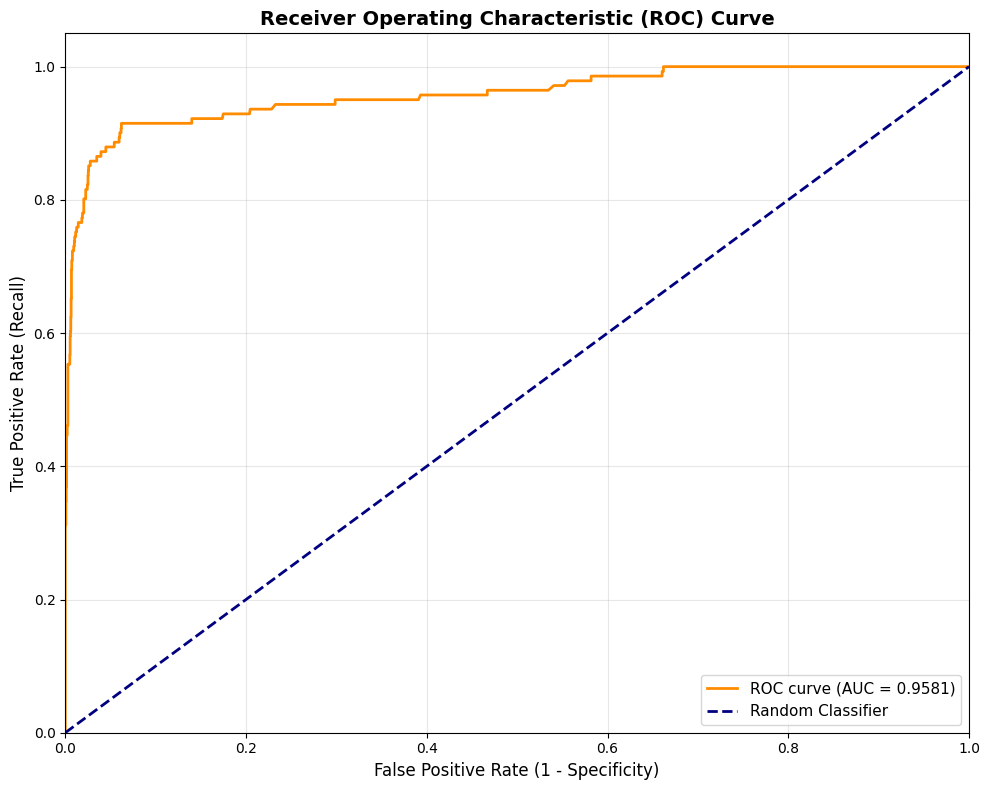

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

threshold_used = 0.50  # best_lgbm.predict() uses 0.5 cutoff for binary class labels
print(f"Threshold (classification cutoff): {threshold_used:.2f}")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba[:, 1])) # Us probabilities of the positive class
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1]) 

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###### Model is highly effective in identifying flood-prone areas (high recall), ensuring minimal missed flood events. However, it produces moderate false positives, which is acceptable in flood prediction where missing an event is more critical than issuing warnings

In [ ]:
# fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.3960409561295656


Threshold (classification cutoff): 0.50
Precision: 0.4979757085020243
Recall: 0.8723404255319149
F1 Score: 0.634020618556701
ROC AUC: 0.9581404998650802
Confusion Matrix:
 [[2662  124]
 [  18  123]]
Ideal Threshold (closest to (0,1)): 0.3960


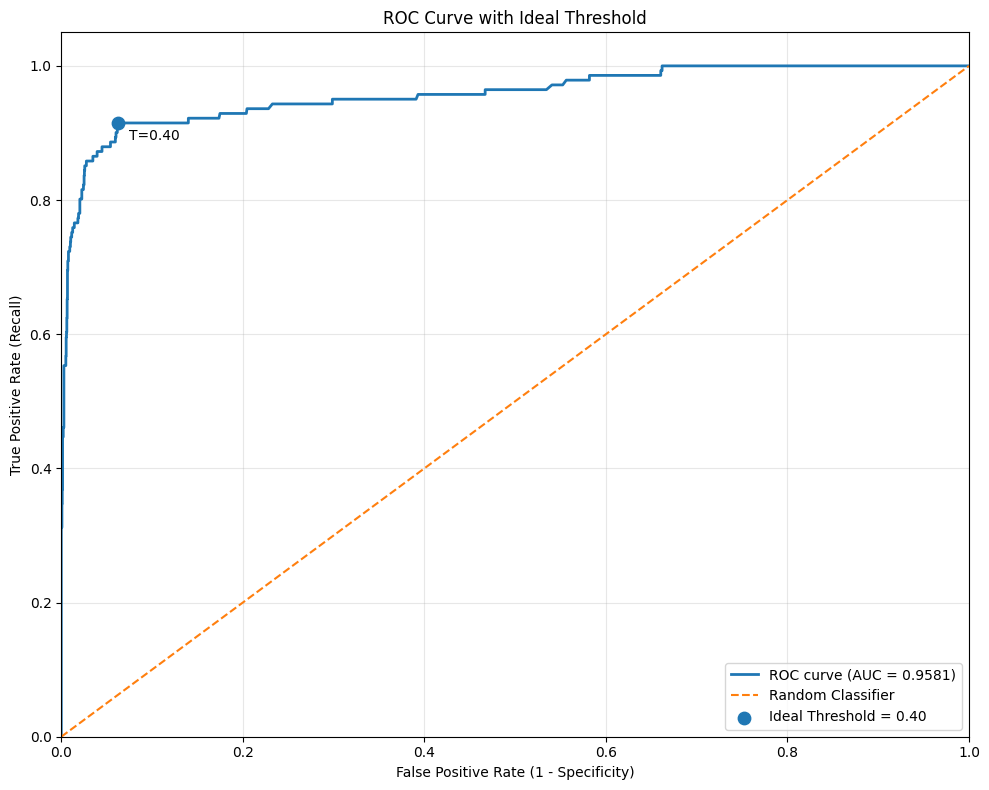

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import numpy as np

threshold_used = 0.50

print(f"Threshold (classification cutoff): {threshold_used:.2f}")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

#  Find point closest to ideal (0,1)
distances = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
best_idx = np.argmin(distances)

ideal_threshold = thresholds[best_idx]
ideal_fpr = fpr[best_idx]
ideal_tpr = tpr[best_idx]

print(f"Ideal Threshold (closest to (0,1)): {ideal_threshold:.4f}")

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

#  Mark ideal point
plt.scatter(ideal_fpr, ideal_tpr, s=80, zorder=5,
            label=f'Ideal Threshold = {ideal_threshold:.2f}')
plt.annotate(f'T={ideal_threshold:.2f}', 
             (ideal_fpr, ideal_tpr),
             textcoords='offset points',
             xytext=(8, -12),
             fontsize=10)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve with Ideal Threshold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Top 10 Features:
          feature  importance
            slope         600
              dem         583
             soil         566
              twi         367
             lulc         345
           aspect         252
distance_to_river         186
 drainage_density         147
flow_accumulation          87
         rainfall          82


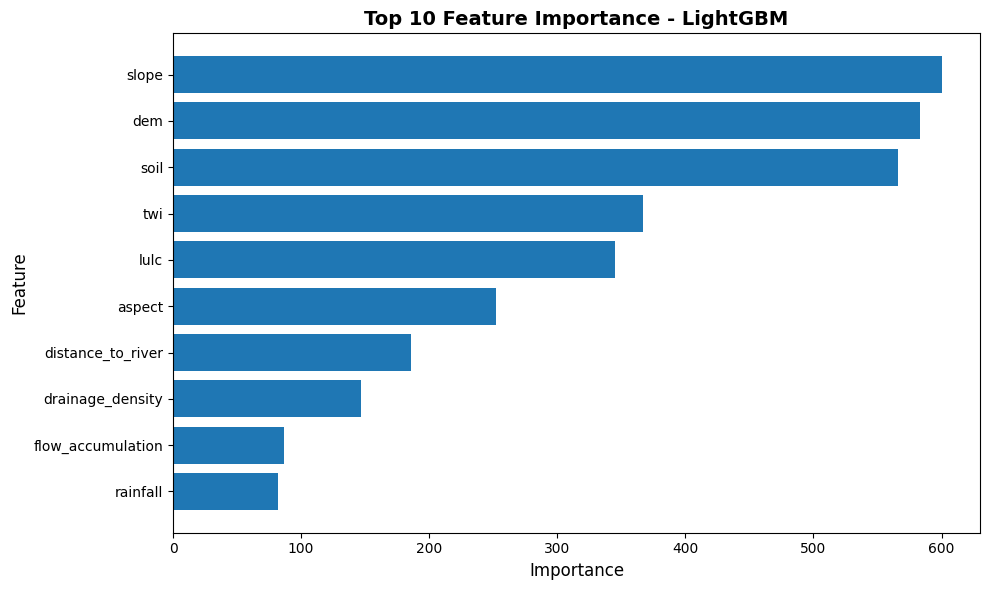

Feature importance plot displayed


In [13]:
feature_importance = (
        pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(10)
    )

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - LightGBM", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


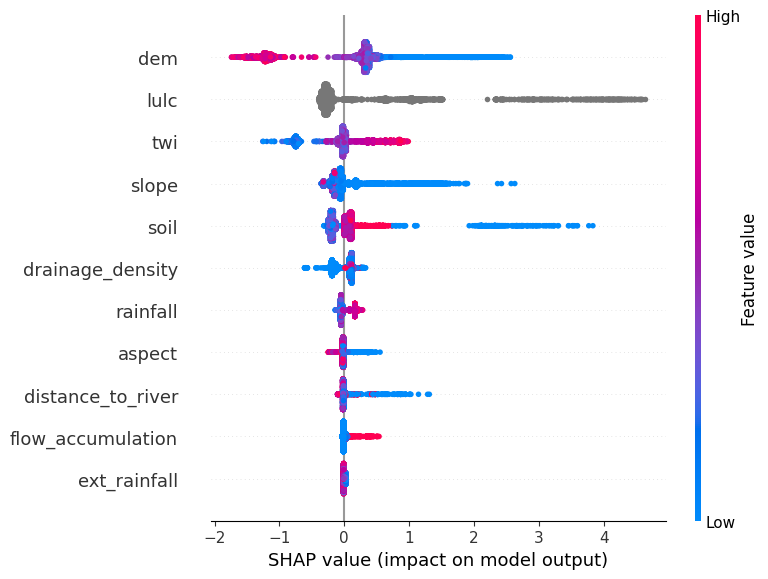

In [15]:
import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)

In [31]:
# Best Threshold finding
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

y_pred_proba = best_lgbm.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

best_threshold = 0.5
best_recall = 0
best_precision = 0
best_f1 = 0

print("Threshold tuning results:\n")

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    print(f"Threshold={t:.2f} | Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f}")

    # choose threshold with highest recall
    # and keep minimum precision so model does not become useless
    if rec > best_recall and prec >= 0.40:
        best_recall = rec
        best_precision = prec
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold Selected:", best_threshold)
print("Best Recall:", best_recall)
print("Best Precision:", best_precision)
print("Best F1:", best_f1)

# Use selected threshold for final prediction
threshold = float(best_threshold)
y_pred_new = (y_pred_proba >= threshold).astype(int)

print("\nEvaluation using best threshold")
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_new, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_new, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))
print("\nClassification Report:\n", classification_report(y_test, y_pred_new, zero_division=0))

Threshold tuning results:

Threshold=0.10 | Recall=0.9504 | Precision=0.1116 | F1=0.1997
Threshold=0.15 | Recall=0.9433 | Precision=0.1567 | F1=0.2687
Threshold=0.20 | Recall=0.9291 | Precision=0.2012 | F1=0.3308
Threshold=0.25 | Recall=0.9149 | Precision=0.2575 | F1=0.4019
Threshold=0.30 | Recall=0.9149 | Precision=0.3440 | F1=0.5000
Threshold=0.35 | Recall=0.9149 | Precision=0.3909 | F1=0.5478
Threshold=0.40 | Recall=0.9007 | Precision=0.4291 | F1=0.5812
Threshold=0.45 | Recall=0.8865 | Precision=0.4529 | F1=0.5995
Threshold=0.50 | Recall=0.8723 | Precision=0.4980 | F1=0.6340
Threshold=0.55 | Recall=0.8652 | Precision=0.5304 | F1=0.6577
Threshold=0.60 | Recall=0.8582 | Precision=0.5789 | F1=0.6914
Threshold=0.65 | Recall=0.8511 | Precision=0.6122 | F1=0.7122
Threshold=0.70 | Recall=0.8369 | Precision=0.6277 | F1=0.7173
Threshold=0.75 | Recall=0.8014 | Precision=0.6457 | F1=0.7152
Threshold=0.80 | Recall=0.7660 | Precision=0.6879 | F1=0.7248
Threshold=0.85 | Recall=0.7447 | Precision=

In [32]:
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

y_pred_new = (y_prob >= threshold).astype(int)

Threshold: 0.40000000000000013
Precision: 0.42905405405405406
Recall: 0.900709219858156
F1 Score: 0.5812356979405034
ROC AUC: 0.9581404998650802
Confusion Matrix:
 [[2617  169]
 [  14  127]]


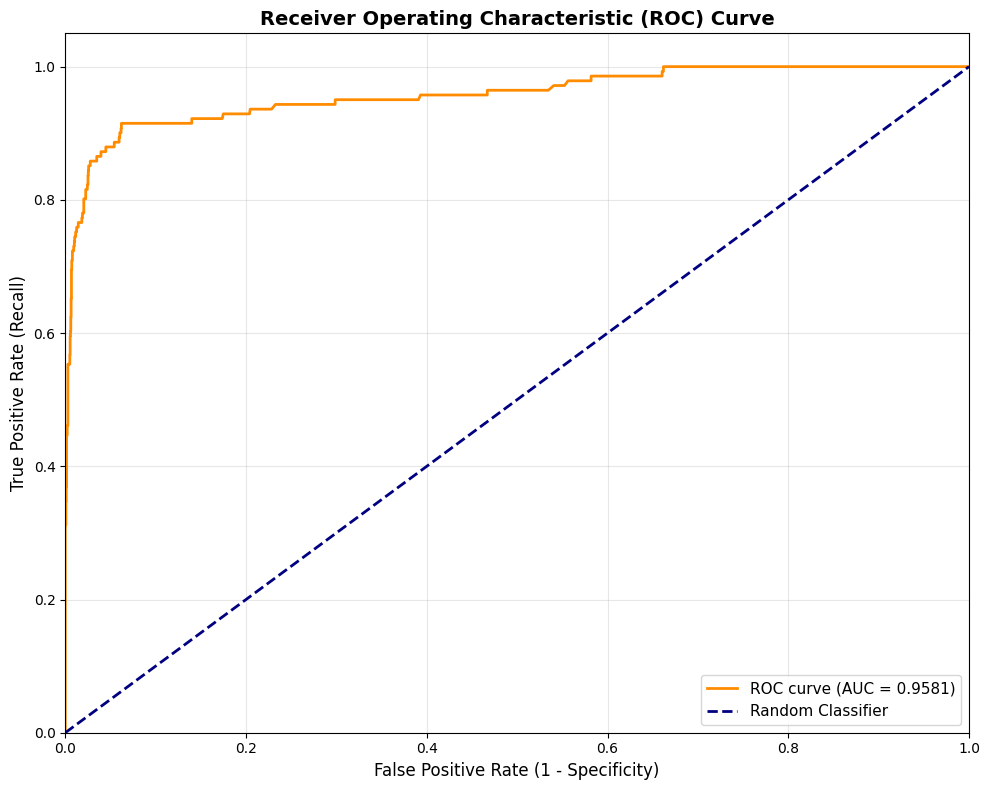

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import numpy as np

print(f"Threshold: {threshold}")
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1 Score:", f1_score(y_test, y_pred_new))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))

# Calculate ROC curve from probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Locate ROC point nearest the selected threshold
finite_mask = np.isfinite(thresholds)
thresholds_f = thresholds[finite_mask]
fpr_f = fpr[finite_mask]
tpr_f = tpr[finite_mask]
idx = int(np.argmin(np.abs(thresholds_f - float(threshold))))
best_fpr = float(fpr_f[idx])
best_tpr = float(tpr_f[idx])

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.scatter(best_fpr, best_tpr, color='crimson', s=80, zorder=5, label=f'Best threshold = {float(threshold):.2f}')
plt.annotate(f'T={float(threshold):.2f}', (best_fpr, best_tpr), textcoords='offset points', xytext=(8, -12), fontsize=10, color='crimson')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Saving the threshold of the model
import joblib

joblib.dump(threshold, "best_lgbm_threshold.pkl")

print("Model and threshold saved successfully.")

Model and threshold saved successfully.


In [39]:
# Loading the threshold
import joblib
threshold_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\lgbm\best_lgbm_threshold.pkl"
loaded_threshold = joblib.load(threshold_path)
loaded_threshold

0.40000000000000013

In [62]:
import pandas as pd

new_data = pd.DataFrame({
    "lulc": [40],
    "slope": [1.2000294],
    "dem": [183.26982],
    "rainfall": [80],
    "flow_accumulation": [18],
    "twi": [10.04377686],
    "drainage_density": [0.008238159],
    "distance_to_river": [10993.2705],
    "aspect": [177.98924],
    "ext_rainfall": [30.77912],
    "soil": [29]
})

In [ ]:
new_data["lulc"] = new_data["lulc"].astype("category")

In [67]:
y_prob = best_lgbm.predict_proba(new_data)[:, 1]
y_pred = (y_prob >= loaded_threshold).astype(int)

print("Prediction:", y_pred[0])
print("Flood Probability:", y_prob[0])

Prediction: 1
Flood Probability: 0.4390681928405511


###### Although drainage density appeared as the most important feature in LightGBM, SHAP analysis indicated that this dominance was likely due to model bias rather than true hydrological significance. Correlation analysis showed it was not strongly related to other flow-related variables, and domain knowledge suggests that elevation and distance to river are more critical for flood occurrence. Therefore, to improve interpretability and ensure physically meaningful predictions, drainage density was excluded and the model was retrained

In [ ]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing", "drainage_density"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'ext_rainfall', 'lulc', 'soil'],
      dtype='object')

In [ ]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###### To improve flood-event detection, the LightGBM model was optimized for recall using stratified cross-validation, class imbalance weighting, and post-training probability threshold tuning. This was done because missing flood-prone locations is more critical than generating additional false alarms

In [ ]:
# Stratified CV
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Stratified CV (important for imbalance)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LightGBM model
lgbm_model = LGBMClassifier(random_state=42)

# Improved hyperparameter grid
param_grid_lgbm = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, -1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_samples": [10, 20, 30],
    "class_weight": [None, "balanced"]
}


In [ ]:
# Grid Search
grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=cv_strategy,
    scoring="recall",
    verbose=2,
    n_jobs=-1
)

In [ ]:
# Load model -> with drainage_density
import joblib

lgbm_model_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\lgbm\best_lgbm_model_wo_dd.pkl"
model = joblib.load(lgbm_model_path)

# use it
best_lgbm = model
print(model.get_params())

{'boosting_type': 'gbdt', 'class_weight': 'balanced', 'colsample_bytree': 0.8, 'importance_type': 'split', 'learning_rate': 0.01, 'max_depth': 3, 'min_child_samples': 10, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': None, 'num_leaves': 15, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 0}


c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
best_lgbm = model
y_pred = best_lgbm.predict(X_test)
y_pred_proba = best_lgbm.predict_proba(X_test)

c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Precision: 0.3177570093457944
Recall: 0.816
F1 Score: 0.45739910313901344
ROC AUC: 0.9253175652173913
Confusion Matrix:
 [[2656  219]
 [  23  102]]


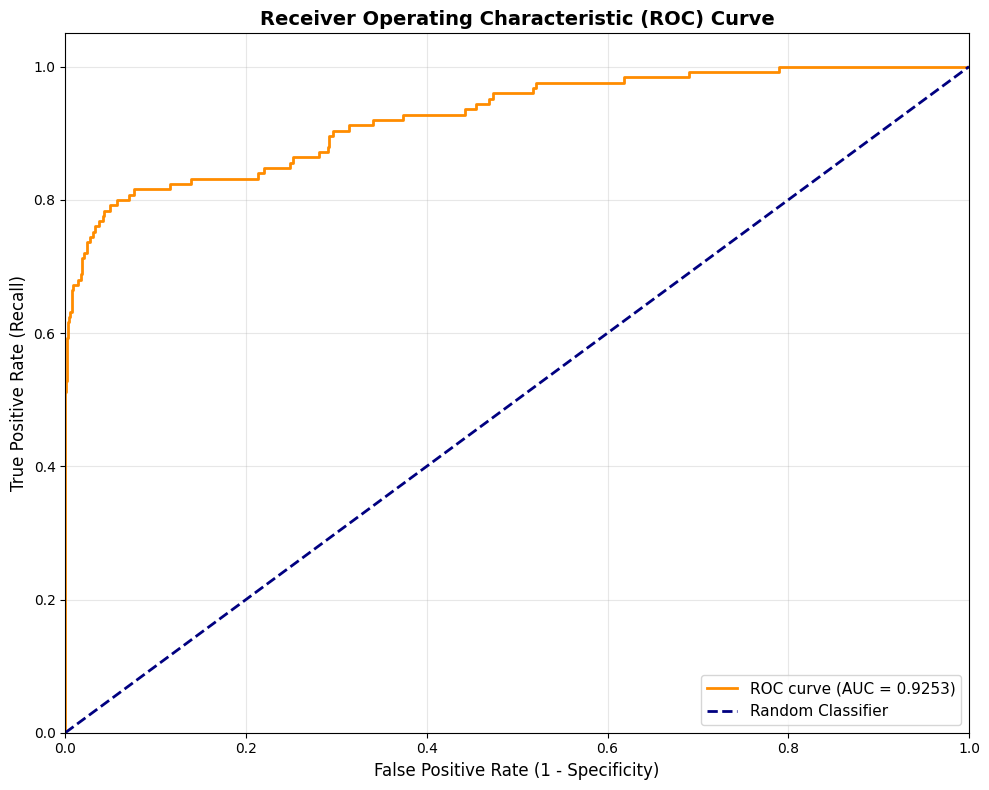

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba[:, 1])) # Use probabilities of the positive class
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1]) # Use probabilities of the positive class

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###### After removing drainage density, the model showed a decrease in overall accuracy but improved recall for the flood class, indicating better detection of actual flood events. Although false positives increased, this trade-off is acceptable in flood susceptibility modeling, where missing a flood event is more critical than issuing a false warning

c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


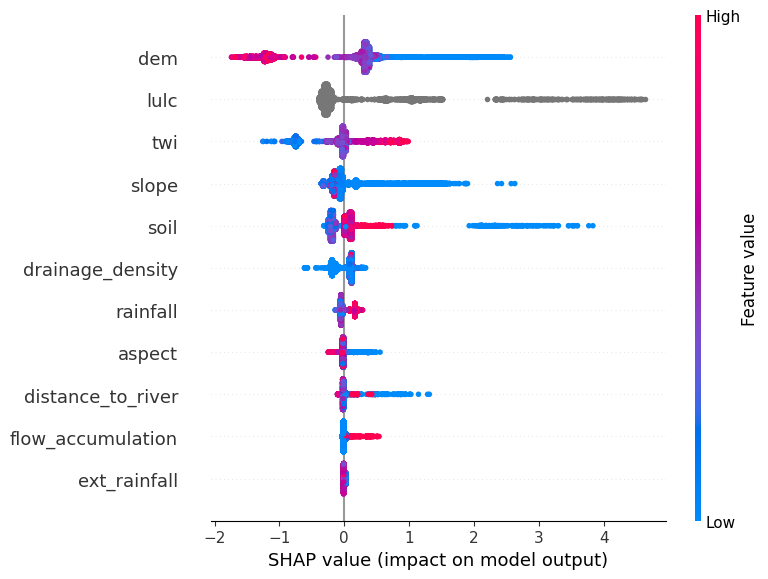

In [14]:
import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)

Model Metrics Comparison


c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Accuracy,Precision,Recall,F1,ROC-AUC,Specificity
LightGBM (with drainage_density),0.9830,0.8304,0.744,0.7848,0.9576,0.9934
LightGBM (without drainage_density),0.9193,0.3178,0.816,0.4574,0.9253,0.9238


Confusion Matrix Values Comparison


,TN,FP,FN,TP
LightGBM (with drainage_density),2856,19,32,93
LightGBM (without drainage_density),2656,219,23,102


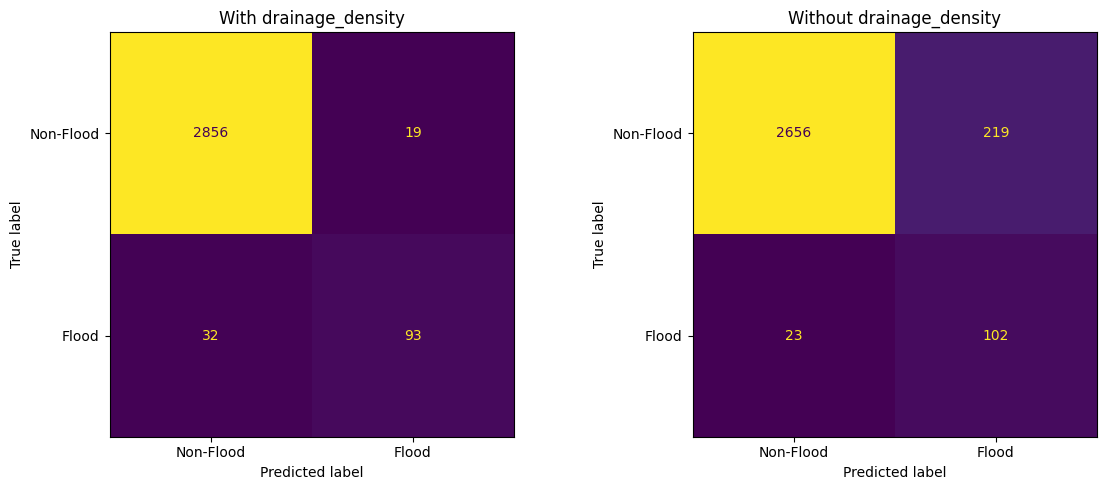

In [ ]:
# Comparison of both saved LightGBM models (with vs without drainage_density)
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate_model(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Specificity": specificity,
    }

    cm = np.array([[tn, fp], [fn, tp]])
    cm_summary = {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

    return metrics, cm, cm_summary


# Build feature sets
y_all = df["flood"]
X_with_dd = df.drop(["flood", "point_id", "easting", "northing"], axis=1)
X_without_dd = df.drop(["flood", "point_id", "easting", "northing", "drainage_density"], axis=1)

# Use same row split for fair comparison
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.3,
    random_state=42,
    stratify=y_all,
)

# With drainage density
scaler_with = StandardScaler()
X_with_train_scaled = scaler_with.fit_transform(X_with_dd.loc[idx_train])
X_with_test_scaled = scaler_with.transform(X_with_dd.loc[idx_test])
X_with_test_scaled = pd.DataFrame(
    X_with_test_scaled,
    columns=X_with_dd.columns,
    index=idx_test,
)
y_test_with = y_all.loc[idx_test]

# Without drainage density
scaler_without = StandardScaler()
X_without_train_scaled = scaler_without.fit_transform(X_without_dd.loc[idx_train])
X_without_test_scaled = scaler_without.transform(X_without_dd.loc[idx_test])
X_without_test_scaled = pd.DataFrame(
    X_without_test_scaled,
    columns=X_without_dd.columns,
    index=idx_test,
)
y_test_without = y_all.loc[idx_test]

# Load both trained models
model_with_dd = joblib.load(r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\lgbm\best_lgbm_model.pkl")
model_without_dd = joblib.load(r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\lgbm\best_lgbm_model_wo_dd.pkl")

# Evaluate both models
metrics_with, cm_with, cm_summary_with = evaluate_model(model_with_dd, X_with_test_scaled, y_test_with)
metrics_without, cm_without, cm_summary_without = evaluate_model(model_without_dd, X_without_test_scaled, y_test_without)

results = {
    "LightGBM (with drainage_density)": metrics_with,
    "LightGBM (without drainage_density)": metrics_without,
}
cm_results = {
    "LightGBM (with drainage_density)": cm_summary_with,
    "LightGBM (without drainage_density)": cm_summary_without,
}

comparison_df = pd.DataFrame(results).T.round(4)
cm_comparison_df = pd.DataFrame(cm_results).T

print("Model Metrics Comparison")
display(comparison_df)

print("Confusion Matrix Values Comparison")
display(cm_comparison_df)

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_with, display_labels=["Non-Flood", "Flood"]).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False,
)
axes[0].set_title("With drainage_density")

ConfusionMatrixDisplay(confusion_matrix=cm_without, display_labels=["Non-Flood", "Flood"]).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False,
)
axes[1].set_title("Without drainage_density")

plt.tight_layout()
plt.show()

In [65]:
# Quick diagnosis for single-point prediction behavior
print('threshold var:', threshold)
print('loaded_threshold:', loaded_threshold)

proba_matrix = best_lgbm.predict_proba(new_data)
print('predict_proba raw:', proba_matrix)

p_flood = float(proba_matrix[0, 1]) if getattr(proba_matrix, 'ndim', 1) == 2 else float(proba_matrix[0])
print('flood probability:', p_flood)

pred_with_threshold = int(p_flood >= float(loaded_threshold))
print('prediction using loaded_threshold:', pred_with_threshold)

pred_with_06 = int(p_flood >= 0.6)
print('prediction using 0.6:', pred_with_06)

threshold var: 0.40000000000000013
loaded_threshold: 0.40000000000000013
predict_proba raw: [[0.56093181 0.43906819]]
flood probability: 0.4390681928405511
prediction using loaded_threshold: 1
prediction using 0.6: 0
